ch9. 1~4 (pg.584-601)


#**9. 추천시스템**

###01. 추천 시스템의 개요와 배경

추천시스템은 특히 온라인에서 진가를 발휘한다. 다양한 상품 이미지와 번잡한 카테고리, 메뉴 구성 등으로 인해 온라인 상에서 제품 선택의 어려움을 겪었을 것이다. 이러한 경험이 쌓이면 온라인 쇼핑에 대한 부정적인 이미지가 강해져 결국 매출 감소로 이어질 수 있다.

**추천 시스템의 유형**

추천 시스템은 크게 콘텐츠 기반 필터링 방식과 협업 필터링 방시그로 나뉜다. 그리고 협업 필터링 방식은 다시 최근접 이웃 협업 필터링과 잠재요인 협업 필터링으로 나뉜다.


### 02. 콘텐츠 기반 필터링 추천 시스템

콘텐츠 기반 필터링 방식은 사용자가 특정한 아이템을 매우 선호하는 경우, 그 아이템과 비슷한 콘텐츠를 가진 다른 아이템을 추천하는 방식이다. 예를 들어 사용자가 특정 영화에 높은 평점을 줬다면, 그 영화의 장르, 출연 배우, 감독, 영화 키워드 등의 콘텐츠와 유사한 다른 영화를 추천해주는 방식이다.

이 방식은 사용자가 높게 평가한 영화의 콘텐츠를 감안해 이와 적절하게 매칭되는 영화를 추천해준다.

### 03. 최근접 이웃 협업 필터링

친구들에게 물어보는 것과 유사하게 사용자가 아이템에 매긴 평점 정보나 상품구매 이력과 같은 사용자 행동 양식만을 기반으로 추천을 수행하는 것이 **협업 필터링 방식**이다.

협업 필터링의 주요 목표는 사용자-아이템 평점 매트릭스와 같은 축적된 사용자 행동 데이터를 기반으로 사용자가 아직 평가하지 않은 아이템을 예측 평가하는 것이다. 그림에서 User1은 Item4에대한 평점이 없다. 협업 필터링은 사용자가 평가한 다른 아이템을 기반으로 사용자가 평가하지 않은 아이템의 예측 평가를 도출하는 방식이다.

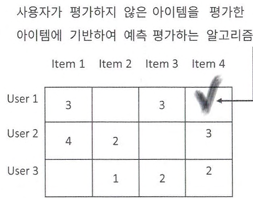



협업 필터링 기반의 추천 시스템은 최근접 이웃 방식과 잠재 요인 방식으로 나뉘며, 두 방식 모두 사용자-아이템 평점 행렬 데이터에만 의지해 추천을 수행한다. 협업 필터링 알고리즘에 사용되는 사용자-아이템 평점 행렬에서 행은 개별 사용자, 열은 개별 아이템으로 구성되며, 사용자 아이디 행, 아이템 아이디 열 위치에 해당하는 값이 평점을 나타내는 형태가 되어야 한다.

만약 데이터가 그림의 왼쪽과 같이 레코드 레벨 형태인 사용자-아이템 평점 데이터라면 판다스의```pivot_table()```과 같은 함수를 이용해 그림의 오른쪽과 같은 형태인 사용자-아이템 평점 행렬 형태로 변경해야 한다.
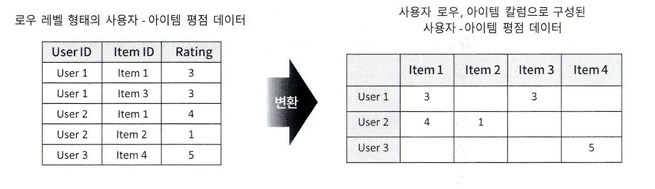

최근접 이웃 협업 필터링은 **메모리 협업 필터링**이라고도 하며 사용자 기반과 아이템 기반으로 다시 나뉠 수 있다.

- 사용자 기반: 당신과 비슷한 고객들이 다음 상품도 구매했습니다
- 아이템 기반: 이 상품을 선택한 다른 고객들은 다음 상품도 구매했습니다.

> 사용자 기반 최근접 이웃 방식

특정 사용자와 유사한 다른 사용자를 Top-N으로 선정해 이 Top-N 사용자가 좋아하는 아이템을 추천하는 방식이다. 즉, 특정 사용자와 타 사용자 간의 유사도를 측정한 뒤 가장 유사도가 높은 Top-N사용자를 추출해 그들이 선호하는 아이템을 추천하는 것이다.


> 아이템 기반 최근접 이웃 방식

아이템이 가지는 속성과는 상관없이 사용자들이 그 아이템을 좋아하는지 싫어하는지의 평가 척도가 유사한 아이템을 추천하는 기준이 되는 알고리즘이다.


일반적으로 사용자 기반보다 아이템 기반 협업 필터링이 정확도가 더 높다. 이유는 비슷한 영화를 좋아한다고 해서 사람들의 취향이 비슷하다고 판단하기는 어려운 경우가 많기 때문이다.


앞장의 텍스트 분석에서 소개된 유사도 측정 방법인 코사인 유사도는 추천시스템의 유사도 측정에 가장 많이 적용된다. 추천 시스템에 사용되는 데이터는 피처 벡터화된 텍스트 데이터와 동일하게 다차원 희소 행렬이라는 특징이 있으므로 유사도 측정을 위해 주로 코사인 유사도를 이용한다.

### 04. 잠재 요인 협업 필터링

잠재요인 협업 필터링은 사용자-아이템 평점 매트릭스 속에 숨어 있는 잠재 요인을 추출해 추천 예측을 할 수 있게 하는 기법이다.

대규모 다차원 행렬을 SVD와 같은 차원 감소 기법으로 분해하는 과정에서 잠재 요인을 추출하는데, 이러한 기법을 행렬 분해라고 한다.

행렬 분해 기반의 잠재 요인 협업 필터링은 넷플릭스 경연 대회에서 사용되면서 유명해졌다.


> 잠재요인 필터링

: 사용자-아이템 평점 행렬 데이터만을 이용해 '잠재요인'을 끄집어 내는 것을 의미

'잠재 요인'이 어떤 것인지 명확히 정의할 수는 없으나, 이를 기반으로 **다차원 희소 행렬인 사용자-아이템 행렬 데이터**를 **저차원 밀집 행렬의 사용자-잠재요인 행렬아이템-잠재요인 행렬의 전치 행렬**로 분해할 수 있다. 이렇게 분해된 두 행렬의 내적을 통해 새로운 예측 사용자-아이템 평점 행렬 데이터를 만들어 사용자가 아직 평점을 부여하지 않은 아이템에 대한 예측 평점을 생성하는 것이 골자이다.



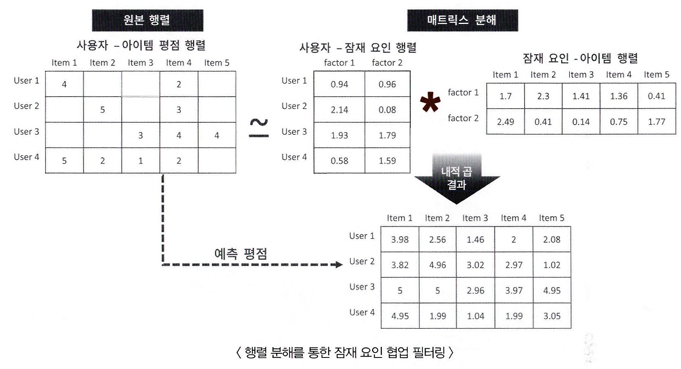

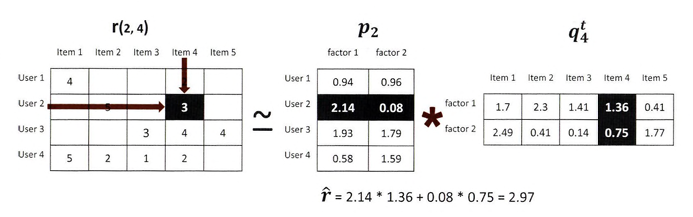

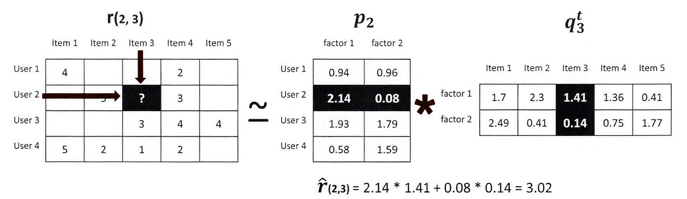

위와 같이 사용자가 평가하지 않은 아이템에 대한 평점도 잠재요인으로 분해된 P행렬과 Q행렬을 이용해 예측할 수 있다.

확률적 경사 하강법은 5장 회귀에서 배운 경사 하강법의 한 종류이다.

P와 Q행렬로 계산된 예측 R행렬 값이 실제 R행렬 값과 가장 최소의 오류를 가질 수 있도록 반복적인 비용 함수 최적화를 통해 P와 Q를 유추해내는 것이다.

확률적 경사 하강법을 이용한 행렬 분해의 전반적인 절차를 보면 이해가 쉽다.

1. P와 Q를 임의의 값을 가진 행렬로 설정
2. P와 Q,T값을 곱해 예측 R 행렬을 계산하고 예측 R행렬과 실제 R행렬에 해당하는 오류 값을 계산
3. 이 오류 값을 최소화할 수 있도록 P와 Q행렬을 적절한 값으로 각각 업데이트]
4. 만족할 만한 오류 값을 가질 때까지 2,3번 작업을 반복하며 P와 Q값을 업데이트해 근사화한다.

실제값과 예측값의 오류 최소화와 L2규제를 고려한 비용 함수식은 다음과 같다.
$$\min \sum (r_{(u,i)} - p_u q_i^t)^2 + \lambda (\|q_i\|^2 + \|p_u\|^2)$$

#### SGD를 이용해 행렬분해를 수행

In [1]:
import numpy as np

#원본 행렬 R 생성, 분해 행렬 P와 Q 초기화, 잠재 요인 차원 K는 3으로 설정
R = np.array([[4,np.nan,np.nan,2,np.nan],
             [np.nan,5,np.nan, 3,1],
             [np.nan, np.nan, 3,4,4],
             [5,2,1,2,np.nan]])
num_users, num_items = R.shape
K=3

#P와 Q행렬의 크기를 지정하고 정규 분포를 가진 임의의 값으로 입력
np.random.seed(1)
P = np.random.normal(scale=1./K, size=(num_users, K))
Q = np.random.normal(scale=1./K, size=(num_items, K))

In [2]:
from sklearn.metrics import mean_squared_error

def get_rmse(R,P,Q, non_zeros):
  error=0
  #두 개의 분해된 행렬 P와 Q.T의 내적으로 예측 R행렬 생성
  full_pred_matrix = np.dot(P,Q.T)

  #실제 R 행렬에서 널이 아닌 값의 위치 인덱스를 추출해 실제 R 행렬과 예측 행렬의 RMSE 추출
  x_non_zero_ind = [non_zero[0] for non_zero in non_zeros]
  y_non_zero_ind = [non_zero[1] for non_zero in non_zeros]
  R_non_zeros = R[x_non_zero_ind, y_non_zero_ind]
  full_pred_matrix_non_zeros = full_pred_matrix[x_non_zero_ind, y_non_zero_ind]
  mse = mean_squared_error(R_non_zeros, full_pred_matrix_non_zeros)
  rmse = np.sqrt(mse)

  return rmse

- SGD기반으로 행렬 분해 수행

In [3]:
# R>0인 행 위치, 열 위치, 값을 non_zeros리스트에 저장
non_zeros = [(i,j,R[i,j]) for i in range(num_users) for j in range(num_items) if R[i,j]>0 ]

steps=1000
learning_rate = 0.01
r_lambda=0.01

#SGD 기법으로 P와 Q 매트릭스를 계속 업데이트
for step in range(steps):
  for i,j, r in non_zeros:
    #실제 값과 예측 값의 차이인 오류 값 구함
    eij = r-np.dot(P[i,:],Q[j,:].T)
    #Regulatization을 반영한 SGD 업데이트 공식 적용
    P[i,:] = P[i,:]+learning_rate*(eij*Q[j,:]-r_lambda*P[i,:])
    Q[j,:] = Q[j,:]+learning_rate*(eij*P[i,:]-r_lambda*Q[j,:])

  rmse = get_rmse(R,P,Q,non_zeros)
  if (step%50)==0:
    print("### iteration step : ", step, " rmse : ", rmse)

### iteration step :  0  rmse :  3.2388050277987723
### iteration step :  50  rmse :  0.4876723101369648
### iteration step :  100  rmse :  0.1564340384819247
### iteration step :  150  rmse :  0.07455141311978046
### iteration step :  200  rmse :  0.04325226798579314
### iteration step :  250  rmse :  0.029248328780878973
### iteration step :  300  rmse :  0.022621116143829466
### iteration step :  350  rmse :  0.019493636196525135
### iteration step :  400  rmse :  0.018022719092132704
### iteration step :  450  rmse :  0.01731968595344266
### iteration step :  500  rmse :  0.016973657887570753
### iteration step :  550  rmse :  0.016796804595895633
### iteration step :  600  rmse :  0.01670132290188466
### iteration step :  650  rmse :  0.01664473691247669
### iteration step :  700  rmse :  0.016605910068210026
### iteration step :  750  rmse :  0.016574200475705
### iteration step :  800  rmse :  0.01654431582921597
### iteration step :  850  rmse :  0.01651375177473524
### iterati

- 분해된 P와 Q함수를 $P*Q.T$로 예측 행렬을 만들어 출력

In [4]:
pred_matrix = np.dot(P, Q.T)
print('예측 행렬:\n', np.round(pred_matrix,3))

예측 행렬:
 [[3.991 0.897 1.306 2.002 1.663]
 [6.696 4.978 0.979 2.981 1.003]
 [6.677 0.391 2.987 3.977 3.986]
 [4.968 2.005 1.006 2.017 1.14 ]]


- 원본 행렬과 비교해 널이 아닌 값은 큰 차이가 나지 않으며, 널인 값은 새로운 예측값으로 채워졌다.